<a href="https://colab.research.google.com/github/shivanivanitha0-dev/mini-project-1/blob/main/crop_yield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      field_id date_of_image   latitude  longitude      NDVI     GNDVI  \
0      Field_1    01-01-2023  22.625231  88.497925  0.060190  0.084801   
1      Field_1    16-01-2023  22.625231  88.497925  0.213957  0.222009   
2      Field_1    31-01-2023  22.625231  88.497925  0.403306  0.431204   
3      Field_1    15-02-2023  22.625231  88.497925  0.418187  0.444132   
4      Field_1    03-02-2023  22.625231  88.497925  0.375138  0.387985   
...        ...           ...        ...        ...       ...       ...   
1620  Field_90    15-06-2023  14.480189  77.593430  0.273514  0.460121   
1621  Field_90    14-08-2023  14.480189  77.593430  0.246901  0.338604   
1622  Field_90    13-10-2023  14.480189  77.593430  0.403294  0.562632   
1623  Field_90    28-10-2023  14.480189  77.593430  0.338009  0.496380   
1624  Field_90    27-12-2023  14.480189  77.593430  0.286447  0.474224   

          NDWI      SAVI  soil_moisture  temperature  
0    -0.084801  0.090280      46.119353     9.884229  
1

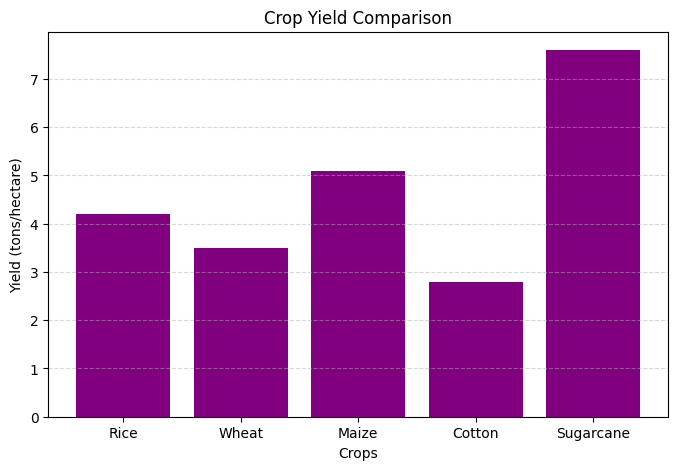

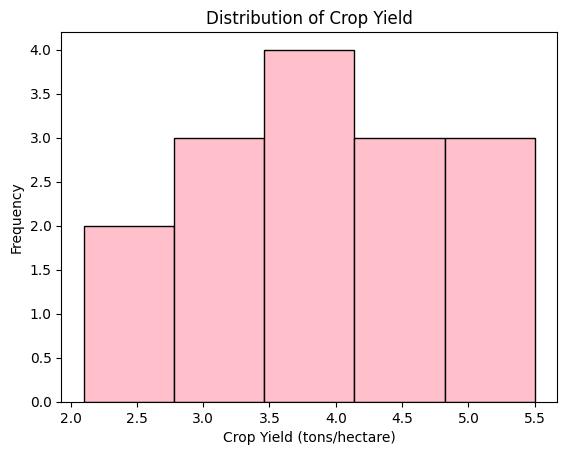

<Figure size 800x500 with 0 Axes>

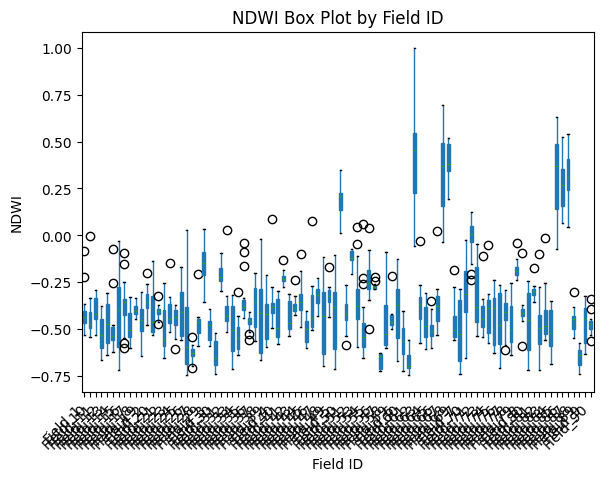

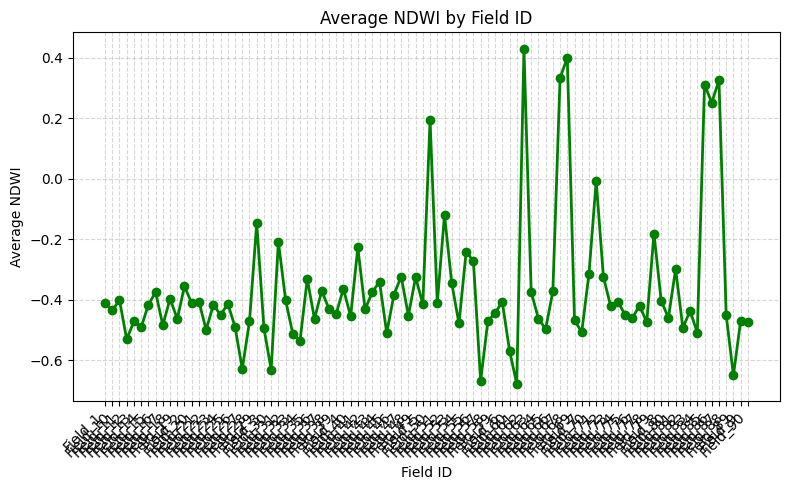

Confusion Matrix:
[[199   2]
 [  3 121]]


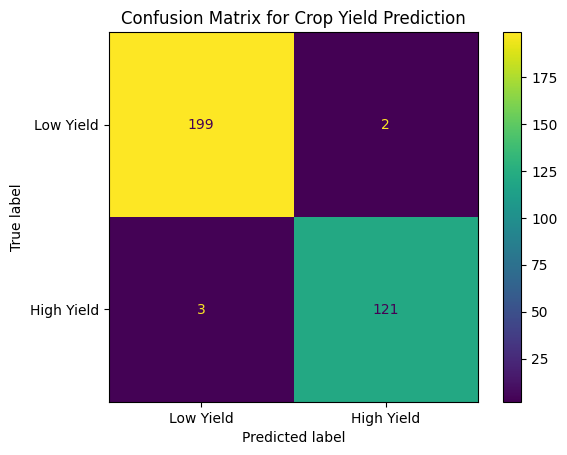

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
Dataset = pd.read_csv("/content/yield_prediction_dataset-selected-columns.csv")
print(Dataset)
print(Dataset.info())
print(Dataset.isnull().sum())
X_raw = Dataset[['soil_moisture', 'temperature', 'field_id']]
X = pd.get_dummies(X_raw, columns=['field_id'], drop_first=False, dtype=bool)
y = Dataset['NDWI']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("\nTraining Data Size :", len(X_train))
print("Testing Data Size  :", len(X_test))
print("\nTraining Machine Learning Model...")
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
print("Model Training Completed Successfully!")
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print("Mean Absolute Error :", round(mae, 3))
print("Mean Squared Error  :", round(mse, 3))
print("RMSE                :", round(rse, 3))
print("R2 Score            :", round(r2, 3))
results = pd.DataFrame({
    'Actual Yield': y_test.values,
    'Predicted Yield': predictions
})

print("\nActual vs Predicted Values")
print(results)
print("\n===================================")
print("CROP YIELD PREDICTION")
print("===================================")
soil_moisture = float(input("Enter soil_moisture: "))
temperature = float(input("Enter Temperature (°C): "))
field_id_input_str = input("Enter field_id (e.g., 'Field_1', 'Field_2', ...): ")
new_data_dict = {
    'soil_moisture': [soil_moisture],
    'temperature': [temperature]
}
field_id_columns_from_xtrain = [col for col in X_train.columns if col.startswith('field_id_')]
for col in field_id_columns_from_xtrain:
    new_data_dict[col] = [False]
target_field_column_name = f'field_id_{field_id_input_str}'
if target_field_column_name in field_id_columns_from_xtrain:
    new_data_dict[target_field_column_name] = [True]
else:

    print(f"Warning: Field ID '{field_id_input_str}' was not found in the training data. Prediction accuracy may be affected.")
new_data = pd.DataFrame(new_data_dict)
new_data = new_data[X_train.columns]
predicted_yield = model.predict(new_data)
print("\n===================================")
print("PREDICTION RESULT")
print("===================================")
print(
    "Estimated Crop Yield :",
    round(predicted_yield[0], 2),
    "tons/hectare"
)

# Adding input prompts for rainfall and humidity, with comma removal
rainfall_str = input("Enter Rainfall (mm): ")
rainfall = float(rainfall_str.replace(',', ''))
humidity_str = input("Enter Humidity (%): ")
humidity = float(humidity_str.replace(',', ''))

prediction_report = pd.DataFrame({
    'Rainfall': [rainfall],
    'Temperature': [temperature],
    'Humidity': [humidity],
    'Predicted_Yield': [round(predicted_yield[0], 2)]
})

prediction_report.to_csv(
    "prediction_result.csv",
    index=False
)

print("\nPrediction saved to prediction_result.csv")

print("\n===================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("===================================")
import matplotlib.pyplot as plt

# Crop data
crops = ["Rice", "Wheat", "Maize", "Cotton", "Sugarcane"]
yield_tons = [4.2, 3.5, 5.1, 2.8, 7.6]

# Create bar graph
plt.figure(figsize=(8, 5))
plt.bar(crops, yield_tons, color=["purple"])

plt.title("Crop Yield Comparison")
plt.xlabel("Crops")
plt.ylabel("Yield (tons/hectare)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()
import matplotlib.pyplot as plt

# Crop yield data in tons/hectare
yield_data = [2.1, 2.5, 2.8, 3.0, 3.2, 3.5, 3.6,
              3.8, 4.0, 4.2, 4.5, 4.7, 5.0, 5.2, 5.5]

# Create histogram
plt.hist(yield_data, bins=5, color="pink", edgecolor="black")

plt.title("Distribution of Crop Yield")
plt.xlabel("Crop Yield (tons/hectare)")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(8, 5))

# Corrected column names for boxplot
Dataset.boxplot(
    column="NDWI",
    by="field_id",
    grid=False,
    patch_artist=True
)

plt.title("NDWI Box Plot by Field ID")
plt.suptitle("") # Remove default suptitle to avoid overlap with title
plt.xlabel("Field ID")
plt.ylabel("NDWI")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.show()
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV dataset (Removed: data = pd.read_csv("crop_yield.csv"))
# The 'data' DataFrame should already be loaded from '/content/yield_prediction_dataset-selected-columns.csv'

# Calculate average NDWI for each field_id
average_ndwi = Dataset.groupby("field_id")["NDWI"].mean()

# Create line graph
plt.figure(figsize=(8, 5))

plt.plot(
    average_ndwi.index,
    average_ndwi.values,
    marker="o",
    color="green",
    linewidth=2
)

plt.title("Average NDWI by Field ID")
plt.xlabel("Field ID")
plt.ylabel("Average NDWI")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert actual and predicted values into classes
threshold = y.mean()  # Average value as threshold

y_test_class = (y_test > threshold).astype(int)
y_pred_class = (predictions > threshold).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test_class, y_pred_class)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Low Yield", "High Yield"])
disp.plot()
plt.title("Confusion Matrix for Crop Yield Prediction")
plt.show()